In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def loss(y, sigmoid):
    return -(y * np.log(sigmoid) + (1 - y) * np.log(1 - sigmoid)).mean()


def predict(x, w, b):
    return np.matmul(w, x.T) + b


def gradient_weights(x, y, n_samples, sigmoid):
    return (np.reshape(sigmoid - y, (n_samples, 1)) * x).mean(axis=0)


def gradient_intercept(y, sig):
    return (sig - y).mean(axis=0)


def update(a, g, lr):
    return a - (g * lr)

Iteration 0 - Loss: 0.6931471805599453
Iteration 100 - Loss: 0.33928965394293037
Iteration 200 - Loss: 0.3328788610392621
Iteration 300 - Loss: 0.3318837420284872
Iteration 400 - Loss: 0.3316743950635375
Iteration 500 - Loss: 0.3316250950577657
Iteration 600 - Loss: 0.33161279707903124
Iteration 700 - Loss: 0.3316096227275368


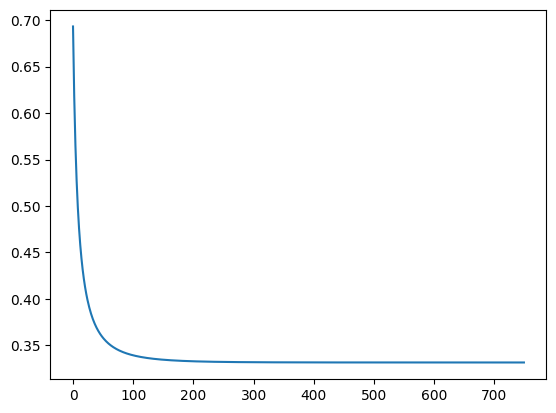

In [9]:
samples = 50
np.random.seed(1984)
clasData = make_classification(n_features=5, n_samples=samples, random_state=1984)
x = clasData[0]
y = clasData[1]
learning_rate = 0.1
n_iter = 1000
b = 0
losses = []
tolerance = 1e-8
best_loss = np.inf
stop = 10
count = 0
w = np.zeros(x.shape[1])
for i in range(n_iter):
    yhat = predict(x, w, b)
    sig = sigmoid(yhat)
    logloss = loss(y, sig)
    if logloss < best_loss - tolerance:
        best_loss = logloss
    else:
        count += 1
    if count == stop:
        break
    losses.append(logloss)
    grad_w = gradient_weights(x, y, samples, sig)
    grad_b = gradient_intercept(y, sig)
    w = update(w, grad_w, learning_rate)
    b = update(b, grad_b, learning_rate)
    if i % 100 == 0:
        print(f"Iteration {i} - Loss: {logloss}")

plt.plot(losses)

In [6]:
from sklearn.metrics import classification_report

yhat = predict(x, w, b)
sigy = sigmoid(yhat)
ypred = sigy >= 0.5
print(classification_report(y, ypred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        24
           1       0.88      0.81      0.84        26

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50

